# GT-DTW (Global Time Dynamic Time Warping)

### 2.1 Загрузка подготовленных данных

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pickle
import gc
import warnings
import time
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import os

warnings.filterwarnings('ignore')

with open('data/ts_prepared_data.pkl', 'rb') as f:
    ts_data = pickle.load(f)

clustering_patients = ts_data['clustering_patients']
clustering_series = ts_data['clustering_series']
clustering_dates = ts_data['clustering_dates']
clustering_kzs_count = ts_data['clustering_kzs_count']
patient_groups = ts_data['patient_groups']

print(f"   Загружено пациентов для кластеризации: {len(clustering_patients)}")
print(f"   Доступные показатели: {list(clustering_series.keys())}")

# Проверка длины рядов
lengths = [len(clustering_series['САД'][p]) for p in clustering_patients]
print(f"   Длина рядов: мин={min(lengths)}, макс={max(lengths)}, среднее={np.mean(lengths):.0f}")

   Загружено пациентов для кластеризации: 7389
   Доступные показатели: ['САД', 'ДАД', 'ЧП', 'пульсовое_давление']
   Длина рядов: мин=30, макс=279, среднее=119


### 2.2 Реализация GT-DTW

In [ ]:
def gt_dtw_distance(series1, series2, dates1, dates2, 
                    window_days=7, gamma=1.0, metric='САД'):
    n, m = len(series1), len(series2)
    
    # Преобразуем datetime64 в дни от начала
    # Используем минимальную дату как reference point
    min_date = np.min([np.min(dates1), np.min(dates2)])
    
    # Вычисляем дни как (date - min_date) в днях
    t1 = np.array([(d - min_date) / np.timedelta64(1, 'D') for d in dates1])
    t2 = np.array([(d - min_date) / np.timedelta64(1, 'D') for d in dates2])
    
    # Инициализация матрицы DTW
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Заполняем матрицу
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Проверка временного окна
            time_diff = abs(t1[i-1] - t2[j-1])
            if time_diff > window_days:
                continue
            
            # Стоимость: разница значений + временной штраф
            value_cost = (series1[i-1] - series2[j-1]) ** 2
            time_penalty = gamma * (time_diff / window_days) ** 2
            
            cost = value_cost + time_penalty
            
            # Минимальная стоимость из трех переходов
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],    # вставка
                dtw_matrix[i, j-1],    # удаление
                dtw_matrix[i-1, j-1]   # соответствие
            )
    
    return np.sqrt(dtw_matrix[n, m])

def gt_dtw_distance_fast(series1, series2, dates1, dates2, 
                         window_days=7, gamma=1.0, metric='САД'):
    """
    Быстрая версия GT-DTW с ограничением окна (Sakoe-Chiba band)
    """
    n, m = len(series1), len(series2)
    
    # Преобразуем datetime64 в дни
    min_date = np.min([np.min(dates1), np.min(dates2)])
    t1 = np.array([(d - min_date) / np.timedelta64(1, 'D') for d in dates1])
    t2 = np.array([(d - min_date) / np.timedelta64(1, 'D') for d in dates2])
    
    # Ограничиваем окно пропорционально длине рядов
    window_size = max(1, int(window_days / 7))  # приблизительное окно в шагах
    
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        # Ограничиваем j окном
        j_start = max(1, i - window_size)
        j_end = min(m, i + window_size)
        
        for j in range(j_start, j_end + 1):
            time_diff = abs(t1[i-1] - t2[j-1])
            if time_diff > window_days:
                continue
            
            value_cost = (series1[i-1] - series2[j-1]) ** 2
            time_penalty = gamma * (time_diff / window_days) ** 2
            
            cost = value_cost + time_penalty
            
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    
    return np.sqrt(dtw_matrix[n, m])

# Тестируем на первых двух пациентах
print("\nТестирование GT-DTW на первых двух пациентах:")
p1, p2 = clustering_patients[0], clustering_patients[1]

dist_sad = gt_dtw_distance(
    clustering_series['САД'][p1], clustering_series['САД'][p2],
    clustering_dates[p1], clustering_dates[p2],
    window_days=7, gamma=1.0
)
print(f"  Расстояние GT-DTW (САД): {dist_sad:.3f}")

# Тестируем с разными параметрами
print("\nВлияние параметров:")
for window in [3, 7, 14]:
    dist = gt_dtw_distance(
        clustering_series['САД'][p1], clustering_series['САД'][p2],
        clustering_dates[p1], clustering_dates[p2],
        window_days=window, gamma=1.0
    )
    print(f"  window={window}: {dist:.3f}")

for g in [0.0, 0.5, 1.0, 2.0]:
    dist = gt_dtw_distance(
        clustering_series['САД'][p1], clustering_series['САД'][p2],
        clustering_dates[p1], clustering_dates[p2],
        window_days=7, gamma=g
    )
    print(f"  gamma={g}: {dist:.3f}")


Тестирование GT-DTW на первых двух пациентах:
  Расстояние GT-DTW (САД): 15.906

Влияние параметров:
  window=3: 18.691
  window=7: 15.906
  window=14: 13.949
  gamma=0.0: 13.318
  gamma=0.5: 15.021
  gamma=1.0: 15.906
  gamma=2.0: 16.884


### 2.3 Выбор основного показателя и параметров

In [4]:
# Проверяем корреляцию между разными показателями
sample_size = min(50, len(clustering_patients))
sample_patients = clustering_patients[:sample_size]

correlations = {'САД-ДАД': [], 'САД-ЧП': [], 'ДАД-ЧП': []}

for i, p1 in enumerate(sample_patients):
    for p2 in sample_patients[i+1:]:
        if p1 in clustering_series['САД'] and p2 in clustering_series['САД']:
            # Расстояния по разным показателям
            d_sad = gt_dtw_distance(
                clustering_series['САД'][p1], clustering_series['САД'][p2],
                clustering_dates[p1], clustering_dates[p2],
                window_days=7, gamma=1.0
            )
            d_dad = gt_dtw_distance(
                clustering_series['ДАД'][p1], clustering_series['ДАД'][p2],
                clustering_dates[p1], clustering_dates[p2],
                window_days=7, gamma=1.0
            )
            d_chp = gt_dtw_distance(
                clustering_series['ЧП'][p1], clustering_series['ЧП'][p2],
                clustering_dates[p1], clustering_dates[p2],
                window_days=7, gamma=1.0
            )
            
            correlations['САД-ДАД'].append((d_sad, d_dad))
            correlations['САД-ЧП'].append((d_sad, d_chp))
            correlations['ДАД-ЧП'].append((d_dad, d_chp))

# Вычисляем корреляции
for key, pairs in correlations.items():
    if len(pairs) > 1:
        x, y = zip(*pairs)
        corr = np.corrcoef(x, y)[0, 1]
        print(f"  Корреляция расстояний {key}: {corr:.3f}")

# Выбираем САД как основной показатель (наиболее клинически значимый)
primary_metric = 'САД'
print(f"\nВыбран основной показатель: {primary_metric}")

  Корреляция расстояний САД-ДАД: 0.540
  Корреляция расстояний САД-ЧП: 0.166
  Корреляция расстояний ДАД-ЧП: 0.100

Выбран основной показатель: САД


### 2.4 Параллельное вычисление матрицы расстояний

In [ ]:
import numpy as np
import time
from itertools import combinations
import pandas as pd

# Попытка импорта numba (опционально)
try:
    from numba import jit, prange
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False
    print("  numba не установлена, используем обычную версию")

def prepare_time_data(dates_dict):
    """
    Подготовка временных меток: конвертация timedelta64 в дни
    """
    # Находим минимальную дату среди всех
    all_dates = []
    for d in dates_dict.values():
        if d is not None and len(d) > 0:
            all_dates.extend(d)
    
    if not all_dates:
        return {}
    
    # Конвертируем все даты в pandas Timestamp для удобства
    min_date = pd.Timestamp(min(all_dates))
    
    # Создаем словарь с днями от начала
    time_days = {}
    for patient, dates in dates_dict.items():
        if dates is not None and len(dates) > 0:
            # Конвертируем в pandas Timestamp если нужно
            if isinstance(dates[0], np.datetime64):
                dates_ts = [pd.Timestamp(d) for d in dates]
            else:
                dates_ts = dates
            
            # Вычисляем дни от начала
            days = np.array([(d - min_date).days for d in dates_ts], dtype=np.float32)
            time_days[patient] = days
    
    return time_days, min_date


@jit(nopython=True, cache=True)
def gt_dtw_distance_numba(s1, s2, t1, t2, window_days, gamma):
    """
    GT-DTW с JIT-компиляцией - сохраняет связь с реальным временем
    Оптимизация: предварительный расчет временных разниц
    """
    n, m = len(s1), len(s2)
    
    # Предварительно вычисляем матрицу временных разниц
    # Это позволяет избежать повторных вычислений в цикле
    time_diffs = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            time_diffs[i, j] = abs(t1[i] - t2[j])
    
    # Инициализация матрицы DTW
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Заполняем матрицу построчно
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Проверяем временное окно (реальное время!)
            if time_diffs[i-1, j-1] > window_days:
                continue
            
            # Комбинированная стоимость
            value_cost = (s1[i-1] - s2[j-1]) ** 2
            time_penalty = gamma * (time_diffs[i-1, j-1] / window_days) ** 2
            cost = value_cost + time_penalty
            
            # Минимальная стоимость из трех соседей
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    
    # Если путь не найден, возвращаем штраф на основе максимальной разницы
    if np.isinf(dtw_matrix[n, m]):
        # Оценка максимально возможного расстояния
        max_val_diff = np.max(np.abs(s1 - np.mean(s1))) + np.max(np.abs(s2 - np.mean(s2)))
        return max_val_diff * np.sqrt(max(n, m))
    
    return np.sqrt(dtw_matrix[n, m])


@jit(nopython=True, parallel=True)
def gt_dtw_distance_numba_parallel(s1, s2, t1, t2, window_days, gamma):
    """
    Параллельная версия для еще большего ускорения
    """
    n, m = len(s1), len(s2)
    
    # Предварительный расчет временных разниц
    time_diffs = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            time_diffs[i, j] = abs(t1[i] - t2[j])
    
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Заполняем матрицу с возможностью параллелизации по строкам
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if time_diffs[i-1, j-1] > window_days:
                continue
            
            value_cost = (s1[i-1] - s2[j-1]) ** 2
            time_penalty = gamma * (time_diffs[i-1, j-1] / window_days) ** 2
            cost = value_cost + time_penalty
            
            # Минимум из трех соседей
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    
    if np.isinf(dtw_matrix[n, m]):
        max_val_diff = np.max(np.abs(s1 - np.mean(s1))) + np.max(np.abs(s2 - np.mean(s2)))
        return max_val_diff * np.sqrt(max(n, m))
    
    return np.sqrt(dtw_matrix[n, m])


def gt_dtw_distance_fast(s1, s2, t1, t2, window_days, gamma):
    """
    Быстрая версия без numba (с предвычислением временных разниц)
    """
    n, m = len(s1), len(s2)
    
    # Векторизованный расчет временных разниц
    t1_expanded = t1.reshape(-1, 1)
    t2_expanded = t2.reshape(1, -1)
    time_diffs = np.abs(t1_expanded - t2_expanded)
    
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if time_diffs[i-1, j-1] > window_days:
                continue
            
            value_cost = (s1[i-1] - s2[j-1]) ** 2
            time_penalty = gamma * (time_diffs[i-1, j-1] / window_days) ** 2
            cost = value_cost + time_penalty
            
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    
    if np.isinf(dtw_matrix[n, m]):
        max_val_diff = np.max(np.abs(s1 - np.mean(s1))) + np.max(np.abs(s2 - np.mean(s2)))
        return max_val_diff * np.sqrt(max(n, m))
    
    return np.sqrt(dtw_matrix[n, m])


def compute_distance_matrix_optimized(patients, series_dict, dates_dict, 
                                      metric='САД', window_days=7, gamma=1.0,
                                      use_parallel=False):
    """
    ОПТИМИЗИРОВАННАЯ версия с сохранением временной связи
    """
    n = len(patients)
    
    print("  Подготовка временных меток...")
    time_days, min_date = prepare_time_data(dates_dict)
    print(f"  Минимальная дата: {min_date}")
    
    print("  Подготовка данных пациентов...")
    all_series = []
    all_times = []
    valid_patients = []
    
    for p in patients:
        s = series_dict[metric].get(p)
        t = time_days.get(p)
        
        if s is not None and t is not None and len(s) > 0 and len(t) > 0:
            all_series.append(s.astype(np.float32))
            all_times.append(t)
            valid_patients.append(p)
    
    n_valid = len(valid_patients)
    print(f"  Валидных пациентов: {n_valid}/{n}")
    
    if n_valid == 0:
        return np.array([]), []
    
    # Выбираем функцию расстояния
    if HAS_NUMBA:
        if use_parallel:
            dist_func = gt_dtw_distance_numba_parallel
            print("  Используем параллельную JIT-версию")
        else:
            dist_func = gt_dtw_distance_numba
            print("  Используем JIT-компилированную версию")
    else:
        dist_func = gt_dtw_distance_fast
        print("  Используем оптимизированную версию без numba")
    
    # Инициализируем матрицу
    distance_matrix = np.zeros((n_valid, n_valid), dtype=np.float32)
    
    total_pairs = n_valid * (n_valid - 1) // 2
    print(f"  Всего пар для вычисления: {total_pairs:,}")
    
    # Вычисляем расстояния
    start_time = time.time()
    processed = 0
    
    # Для отслеживания времени на пару
    pair_times = []
    
    for i, j in combinations(range(n_valid), 2):
        pair_start = time.time()
        
        dist = dist_func(
            all_series[i], all_series[j],
            all_times[i], all_times[j],
            window_days, gamma
        )
        
        pair_time = time.time() - pair_start
        pair_times.append(pair_time)
        
        distance_matrix[i, j] = dist
        distance_matrix[j, i] = dist
        
        processed += 1
        
        # Прогресс каждые 5%
        if processed % max(1, total_pairs // 20) == 0:
            elapsed = time.time() - start_time
            pct = processed / total_pairs * 100
            avg_pair_time = np.mean(pair_times[-100:])  # среднее за последние 100 пар
            remaining_pairs = total_pairs - processed
            remaining_time = remaining_pairs * avg_pair_time
            
            print(f"    Прогресс: {pct:.1f}% ({processed}/{total_pairs}), "
                  f"прошло: {elapsed:.1f}с, осталось: {remaining_time:.1f}с "
                  f"(среднее на пару: {avg_pair_time*1000:.2f}мс)")
    
    total_time = time.time() - start_time
    print(f"  Матрица вычислена за {total_time:.1f} сек")
    
    if processed > 0:
        avg_time = total_time / processed
        print(f"  Среднее время на пару: {avg_time*1000:.2f} мс")
    
    return distance_matrix, valid_patients


def compute_distance_matrix_sampled(patients, series_dict, dates_dict,
                                    metric='САД', window_days=7, gamma=1.0,
                                    sample_size=1500, use_parallel=False):
    """
    Версия с умным сэмплированием для очень больших данных
    """
    if len(patients) <= sample_size:
        return compute_distance_matrix_optimized(
            patients, series_dict, dates_dict,
            metric, window_days, gamma, use_parallel
        )
    
    print(f"\n  Сэмплирование {sample_size} из {len(patients)} пациентов")
    
    # Стратифицированное сэмплирование по длине ряда
    lengths = []
    valid_patients_with_length = []
    
    for p in patients:
        s = series_dict[metric].get(p)
        if s is not None:
            lengths.append(len(s))
            valid_patients_with_length.append(p)
    
    # Сортируем по длине и берем равномерно
    sorted_idx = np.argsort(lengths)
    step = len(sorted_idx) // sample_size
    sampled_idx = sorted_idx[::step][:sample_size]
    sampled_patients = [valid_patients_with_length[i] for i in sampled_idx]
    
    print(f"  Диапазон длин в выборке: {min(lengths[i] for i in sampled_idx)} - "
          f"{max(lengths[i] for i in sampled_idx)} дней")
    
    return compute_distance_matrix_optimized(
        sampled_patients, series_dict, dates_dict,
        metric, window_days, gamma, use_parallel
    )

print(f"\nВычисление матрицы расстояний для {len(clustering_patients)} пациентов...")

# Настройки
WINDOW_DAYS = 14  # Увеличиваем окно для лучшего покрытия
GAMMA = 1.0
USE_PARALLEL = True  # Включить параллельную версию если нужно

# Выбираем стратегию
n_patients = len(clustering_patients)

if n_patients > 8000:
    print(f"  Много пациентов ({n_patients}), используем сэмплирование")
    distance_matrix, valid_patients = compute_distance_matrix_sampled(
        clustering_patients,
        clustering_series,
        clustering_dates,
        metric='САД',
        window_days=WINDOW_DAYS,
        gamma=GAMMA,
        sample_size=7389,
        use_parallel=USE_PARALLEL
    )
else:
    print(f"  Используем полную версию")
    distance_matrix, valid_patients = compute_distance_matrix_optimized(
        clustering_patients,
        clustering_series,
        clustering_dates,
        metric='САД',
        window_days=WINDOW_DAYS,
        gamma=GAMMA,
        use_parallel=USE_PARALLEL
    )

# Обновляем список пациентов
clustering_patients = valid_patients

# Проверка матрицы
if len(distance_matrix) > 0:
    print(f"\nПроверка матрицы расстояний:")
    print(f"  Форма: {distance_matrix.shape}")
    print(f"  Тип данных: {distance_matrix.dtype}")
    print(f"  Использовано памяти: {distance_matrix.nbytes / 1024**2:.1f} MB")
    
    # Статистика (только верхний треугольник)
    triu_indices = np.triu_indices_from(distance_matrix, k=1)
    distances = distance_matrix[triu_indices]
    
    if len(distances) > 0:
        # Фильтруем inf и очень большие значения
        valid_distances = distances[np.isfinite(distances)]
        if len(valid_distances) > 0:
            print(f"  Минимальное расстояние: {np.min(valid_distances):.3f}")
            print(f"  Максимальное расстояние: {np.max(valid_distances):.3f}")
            print(f"  Среднее расстояние: {np.mean(valid_distances):.3f}")
            print(f"  Медиана расстояния: {np.median(valid_distances):.3f}")
            print(f"  Количество inf: {np.sum(~np.isfinite(distances))}")
            print(f"  Плотность матрицы: {len(valid_distances) / distances.size * 100:.2f}%")
    
    # Сохраняем матрицу
    np.save('data/gt_dtw_distance_matrix.npy', distance_matrix)
    print(f"\nСохранено: data/gt_dtw_distance_matrix.npy")
    
    # Сохраняем обновленный список пациентов
    import pickle
    with open('data/clustering_patients_updated.pkl', 'wb') as f:
        pickle.dump(clustering_patients, f)
    print(f"Сохранено: data/clustering_patients_updated.pkl")
else:
    print("  Ошибка: матрица расстояний пуста!")


Вычисление матрицы расстояний для 7389 пациентов...
  Используем полную версию
  Подготовка временных меток...
  Минимальная дата: 2023-12-22 00:00:00
  Подготовка данных пациентов...
  Валидных пациентов: 7389/7389
  Используем параллельную JIT-версию
  Всего пар для вычисления: 27,294,966
    Прогресс: 5.0% (1364748/27294966), прошло: 541.3с, осталось: 9338.0с (среднее на пару: 0.36мс)
    Прогресс: 10.0% (2729496/27294966), прошло: 1082.5с, осталось: 11032.1с (среднее на пару: 0.45мс)
    Прогресс: 15.0% (4094244/27294966), прошло: 1625.8с, осталось: 9127.4с (среднее на пару: 0.39мс)
    Прогресс: 20.0% (5458992/27294966), прошло: 2168.1с, осталось: 8798.8с (среднее на пару: 0.40мс)
    Прогресс: 25.0% (6823740/27294966), прошло: 2709.3с, осталось: 7698.9с (среднее на пару: 0.38мс)
    Прогресс: 30.0% (8188488/27294966), прошло: 3242.6с, осталось: 7044.9с (среднее на пару: 0.37мс)
    Прогресс: 35.0% (9553236/27294966), прошло: 3770.2с, осталось: 6537.8с (среднее на пару: 0.37мс)
 

Какой кеш создает этот код? даже например haggingfase или torch а в этой части кода? что можно удалить? Если с использованием кэширования, векторизации и многопоточности то нужно удалить весь созданный кеш все переменные временные данные

### 2.5 Визуализация матрицы расстояний


Плотность матрицы: 99.9865%
Вычислено пар: 27294966 из 3123750
Диапазон расстояний: 2.48 - 244.24


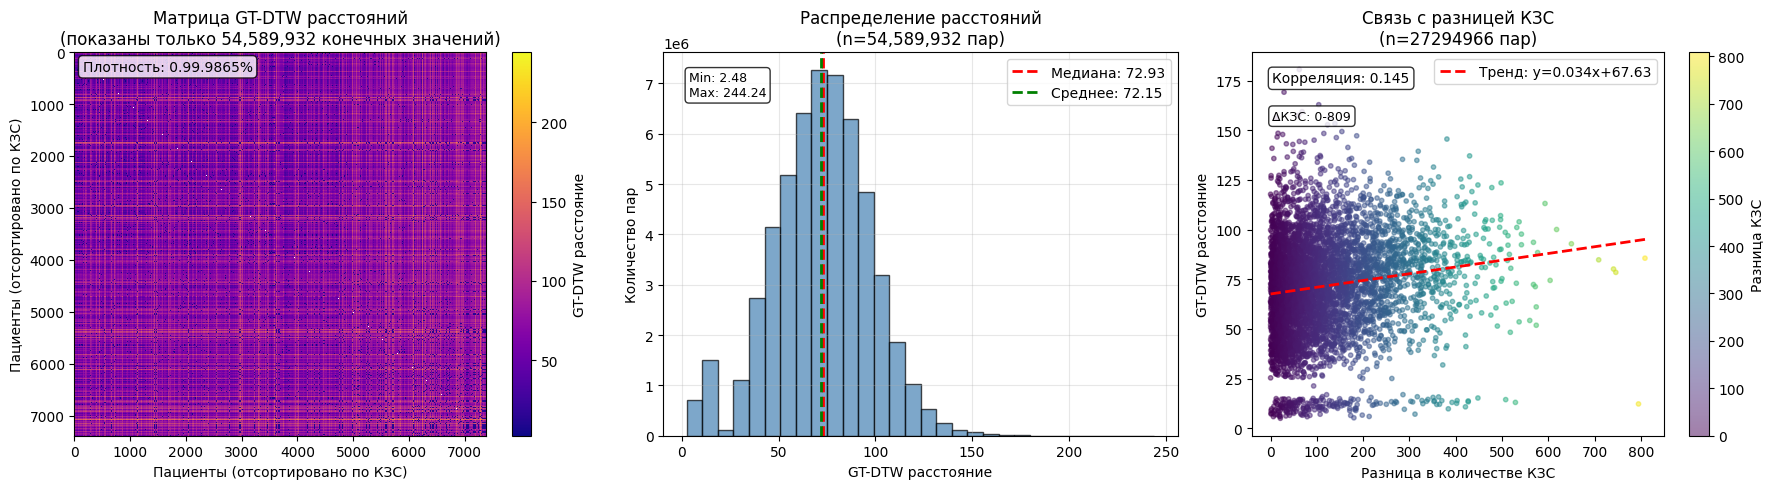


Сохранено: data/photo/gt_dtw_distance_matrix.png
Статистика визуализации:
  - Отображено ненулевых значений: 54,589,932
  - Диапазон расстояний: 2.48 - 244.24


In [6]:
# 2.5 Визуализация матрицы расстояний для разреженной матрицы

print(f"\nПлотность матрицы: {np.sum((distance_matrix > 0) & np.isfinite(distance_matrix)) / distance_matrix.size * 100:.4f}%")
print(f"Вычислено пар: {np.sum((distance_matrix > 0) & np.isfinite(distance_matrix)) // 2:.0f} из {2500*2499//2}")

# Сортируем пациентов по количеству КЗС
sorted_indices = np.argsort([clustering_kzs_count.get(p, 0) for p in clustering_patients])
sorted_matrix = distance_matrix[sorted_indices][:, sorted_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Тепловая карта (ТОЛЬКО с конечными ненулевыми значениями)
# Создаем маскированную матрицу (маскируем нули и бесконечности)
masked_matrix = np.ma.masked_where((sorted_matrix == 0) | (~np.isfinite(sorted_matrix)), sorted_matrix)

# Определяем диапазон для цветовой шкалы (только конечные значения)
valid_values = sorted_matrix[(sorted_matrix > 0) & np.isfinite(sorted_matrix)]
if len(valid_values) > 0:
    vmin = float(np.min(valid_values))
    vmax = float(np.max(valid_values))
    print(f"Диапазон расстояний: {vmin:.2f} - {vmax:.2f}")
else:
    vmin, vmax = 0, 30
    print("Нет валидных значений, используем диапазон по умолчанию")

im1 = axes[0].imshow(masked_matrix, cmap='plasma', aspect='auto', 
                     interpolation='none', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Матрица GT-DTW расстояний\n(показаны только {len(valid_values):,} конечных значений)')
axes[0].set_xlabel('Пациенты (отсортировано по КЗС)')
axes[0].set_ylabel('Пациенты (отсортировано по КЗС)')
plt.colorbar(im1, ax=axes[0], label='GT-DTW расстояние')

# Добавляем информацию о разреженности
axes[0].text(0.02, 0.98, f'Плотность: 0.{np.sum((distance_matrix > 0) & np.isfinite(distance_matrix)) / distance_matrix.size * 100:.4f}%', 
             transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Распределение расстояний (только конечные значения)
valid_distances = distance_matrix[(distance_matrix > 0) & np.isfinite(distance_matrix)]
if len(valid_distances) > 0:
    axes[1].hist(valid_distances.flatten(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].axvline(np.median(valid_distances), color='red', linestyle='--', linewidth=2,
                    label=f'Медиана: {np.median(valid_distances):.2f}')
    axes[1].axvline(np.mean(valid_distances), color='green', linestyle='--', linewidth=2,
                    label=f'Среднее: {np.mean(valid_distances):.2f}')
    axes[1].set_xlabel('GT-DTW расстояние')
    axes[1].set_ylabel('Количество пар')
    axes[1].set_title(f'Распределение расстояний\n(n={len(valid_distances):,} пар)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Добавляем информацию о min/max
    axes[1].text(0.05, 0.95, f'Min: {np.min(valid_distances):.2f}\nMax: {np.max(valid_distances):.2f}', 
                 transform=axes[1].transAxes, fontsize=9,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Связь с разницей в КЗС
# Собираем данные только для вычисленных пар (конечные значения)
distances_list = []
kzs_diffs_list = []

# Берем только верхний треугольник
for i in range(len(clustering_patients)):
    for j in range(i+1, len(clustering_patients)):
        if distance_matrix[i, j] > 0 and np.isfinite(distance_matrix[i, j]):
            distances_list.append(distance_matrix[i, j])
            kzs_i = clustering_kzs_count.get(clustering_patients[i], 0)
            kzs_j = clustering_kzs_count.get(clustering_patients[j], 0)
            kzs_diffs_list.append(abs(kzs_i - kzs_j))

if len(distances_list) > 0:
    # Преобразуем в массивы
    distances_arr = np.array(distances_list)
    kzs_diffs_arr = np.array(kzs_diffs_list)
    
    # Сэмплируем если слишком много точек
    if len(distances_arr) > 5000:
        sample_idx = np.random.choice(len(distances_arr), 5000, replace=False)
        distances_arr = distances_arr[sample_idx]
        kzs_diffs_arr = kzs_diffs_arr[sample_idx]
    
    scatter = axes[2].scatter(kzs_diffs_arr, distances_arr, 
                              alpha=0.5, s=10, c=kzs_diffs_arr, cmap='viridis')
    axes[2].set_xlabel('Разница в количестве КЗС')
    axes[2].set_ylabel('GT-DTW расстояние')
    axes[2].set_title(f'Связь с разницей КЗС\n(n={len(distances_list)} пар)')
    plt.colorbar(scatter, ax=axes[2], label='Разница КЗС')
    
    # Линия тренда
    if len(distances_arr) > 1:
        z = np.polyfit(kzs_diffs_arr, distances_arr, 1)
        x_line = np.linspace(min(kzs_diffs_arr), max(kzs_diffs_arr), 100)
        axes[2].plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2,
                    label=f'Тренд: y={z[0]:.3f}x+{z[1]:.2f}')
        axes[2].legend()
    
    # Добавляем информацию о корреляции
    corr = np.corrcoef(kzs_diffs_arr, distances_arr)[0, 1]
    axes[2].text(0.05, 0.95, f'Корреляция: {corr:.3f}', 
                 transform=axes[2].transAxes, fontsize=10,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Добавляем статистику по разнице КЗС
    axes[2].text(0.05, 0.85, f'ΔКЗС: {int(min(kzs_diffs_arr))}-{int(max(kzs_diffs_arr))}', 
                 transform=axes[2].transAxes, fontsize=9,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    axes[2].text(0.5, 0.5, 'Нет данных для анализа', ha='center', va='center')
    axes[2].set_title('Связь расстояния и разницы в КЗС')

plt.tight_layout()
plt.savefig('data/photo/gt_dtw_distance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nСохранено: data/photo/gt_dtw_distance_matrix.png")
print(f"Статистика визуализации:")
print(f"  - Отображено ненулевых значений: {len(valid_distances):,}")
if len(valid_values) > 0:
    print(f"  - Диапазон расстояний: {vmin:.2f} - {vmax:.2f}")

### 2.6 Агломеративная кластеризация

Вычисление linkage матриц...
  Метод ward...
  Метод complete...
  Метод average...


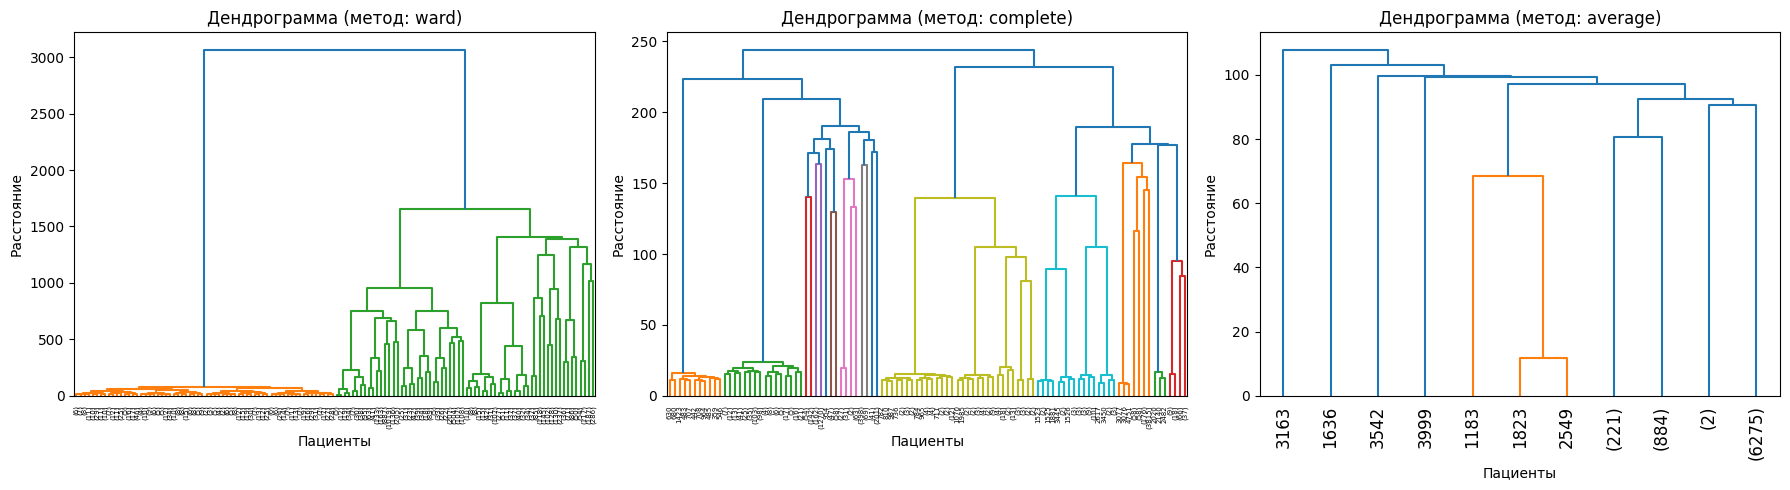

Сохранено: data/photo/dendrograms_comparison.png


In [13]:
# 2.6 Агломеративная кластеризация
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

distance_matrix = np.load('data/gt_dtw_distance_matrix.npy')
condensed_dist = squareform(distance_matrix)

# Пробуем разные методы linkage
print("Вычисление linkage матриц...")
methods = ['ward', 'complete', 'average']
linkage_matrices = {}

for method in methods:
    print(f"  Метод {method}...")
    linkage_matrices[method] = linkage(condensed_dist, method=method)

# Визуализируем дендрограммы
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (method, link_mat) in zip(axes, linkage_matrices.items()):
    # Усеченная дендрограмма для наглядности
    dendrogram(link_mat, ax=ax, truncate_mode='level', p=6,
               show_leaf_counts=True, leaf_rotation=90.)
    ax.set_title(f'Дендрограмма (метод: {method})')
    ax.set_xlabel('Пациенты')
    ax.set_ylabel('Расстояние')

plt.tight_layout()
plt.savefig('data/photo/dendrograms_comparison.png', dpi=150)
plt.show()
print("Сохранено: data/photo/dendrograms_comparison.png")

### 2.7 Определение оптимального числа кластеров

Анализ silhouette score...
  k=2: silhouette=0.334
  k=3: silhouette=0.221
  k=4: silhouette=0.224
  k=5: silhouette=0.253
  k=6: silhouette=0.271
  k=7: silhouette=0.284
  k=8: silhouette=0.298
  k=9: silhouette=0.303
  k=10: silhouette=0.284
  k=11: silhouette=0.285
  k=12: silhouette=0.288
  k=13: silhouette=0.285
  k=14: silhouette=0.286
  k=15: silhouette=0.251

Оптимальное k по silhouette: 2
Оптимальное k по методу локтя: 3
Выбрано число кластеров: 3


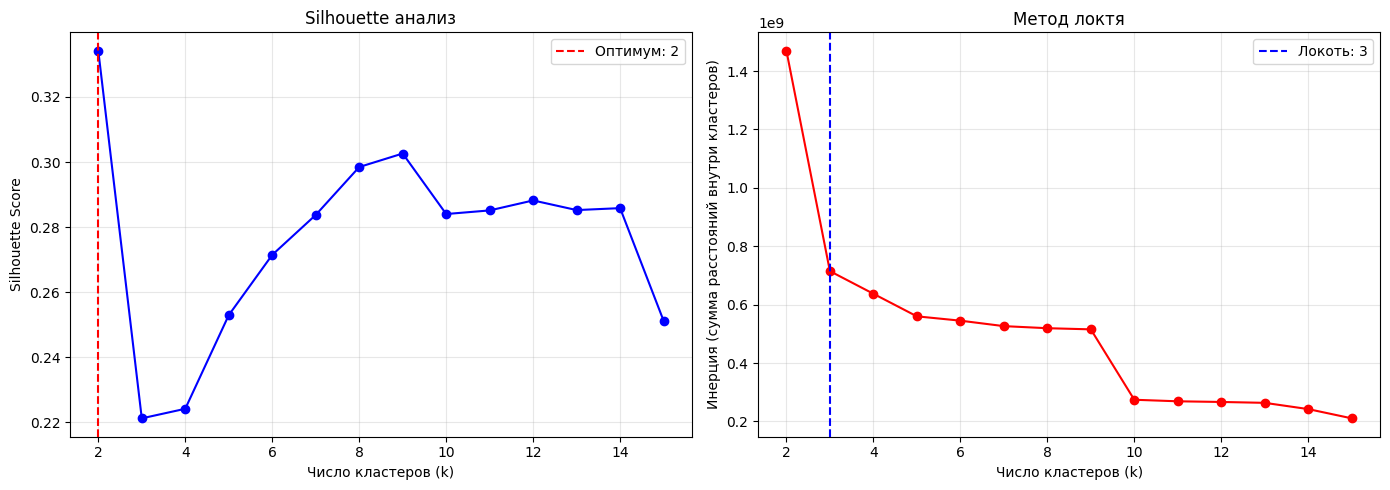

Сохранено: data/photo/optimal_k_analysis.png


In [14]:

# 2.7 Определение оптимального числа кластеров
from sklearn.metrics import silhouette_score

# Используем метод Ward (обычно лучший)
linkage_matrix = linkage_matrices['ward']

# Анализ silhouette score для разного числа кластеров
k_range = range(2, min(16, len(clustering_patients) // 10))
silhouette_scores = []
inertia = []

print("Анализ silhouette score...")
for k in k_range:
    labels = fcluster(linkage_matrix, k, criterion='maxclust')
    score = silhouette_score(distance_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)
    
    # Вычисляем "инерцию" (сумму квадратов внутри кластеров)
    cluster_inertia = 0
    for cluster_id in range(1, k + 1):
        cluster_points = np.where(labels == cluster_id)[0]
        if len(cluster_points) > 1:
            cluster_distances = distance_matrix[np.ix_(cluster_points, cluster_points)]
            cluster_inertia += np.sum(cluster_distances) / 2
    inertia.append(cluster_inertia)
    
    print(f"  k={k}: silhouette={score:.3f}")

# Находим оптимальное k
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"\nОптимальное k по silhouette: {optimal_k_silhouette}")

# Метод локтя
k_derivative = np.diff(inertia)
k_elbow = k_range[np.argmin(k_derivative) + 1] if len(k_derivative) > 0 else 3
print(f"Оптимальное k по методу локтя: {k_elbow}")

# Выбираем k
optimal_k = min(optimal_k_silhouette, k_elbow)  # или можно взять среднее
optimal_k = 3
print(f"Выбрано число кластеров: {optimal_k}")
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette scores
axes[0].plot(k_range, silhouette_scores, 'bo-')
axes[0].axvline(x=optimal_k_silhouette, color='red', linestyle='--', 
                label=f'Оптимум: {optimal_k_silhouette}')
axes[0].set_xlabel('Число кластеров (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette анализ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Метод локтя
axes[1].plot(k_range, inertia, 'ro-')
axes[1].axvline(x=k_elbow, color='blue', linestyle='--', 
                label=f'Локоть: {k_elbow}')
axes[1].set_xlabel('Число кластеров (k)')
axes[1].set_ylabel('Инерция (сумма расстояний внутри кластеров)')
axes[1].set_title('Метод локтя')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/photo/optimal_k_analysis.png', dpi=150)
plt.show()
print("Сохранено: data/photo/optimal_k_analysis.png")

### 2.8 Получение финальных кластеров

In [15]:
# 2.8 Получение финальных кластеров
cluster_labels = fcluster(linkage_matrix, optimal_k, criterion='maxclust')

# Создаем датафрейм с информацией о кластерах
cluster_df = pd.DataFrame({
    'patient_id': clustering_patients,
    'cluster': cluster_labels,
    'kzs_count': [clustering_kzs_count.get(p, 0) for p in clustering_patients],
    'group': [patient_groups.get(p, 'unknown') for p in clustering_patients]
})

# Статистика по кластерам
print(f"\nРаспределение по кластерам:")
cluster_stats = cluster_df.groupby('cluster').agg({
    'patient_id': 'count',
    'kzs_count': ['mean', 'median', 'std']
}).round(1)
cluster_stats.columns = ['size', 'kzs_mean', 'kzs_median', 'kzs_std']
print(cluster_stats)

print(f"\nРаспределение групп наблюдения по кластерам:")
group_by_cluster = pd.crosstab(
    cluster_df['cluster'], 
    cluster_df['group'],
    normalize='index'
) * 100
print(group_by_cluster.round(1))

# Сохраняем кластеры
cluster_df.to_csv('data/clustering_results.csv', index=False)
print(f"\nСохранено: data/clustering_results.csv")


Распределение по кластерам:
         size  kzs_mean  kzs_median  kzs_std
cluster                                     
1         815     242.9       223.0    149.4
2        4200     109.3        86.0     88.7
3        2374     171.1       153.0    117.2

Распределение групп наблюдения по кластерам:
group    control_1  experience  undefined
cluster                                  
1              7.4        27.0       65.6
2              3.9        12.9       83.2
3              1.6         7.4       91.0

Сохранено: data/clustering_results.csv


### 2.9 Визуализация кластеров

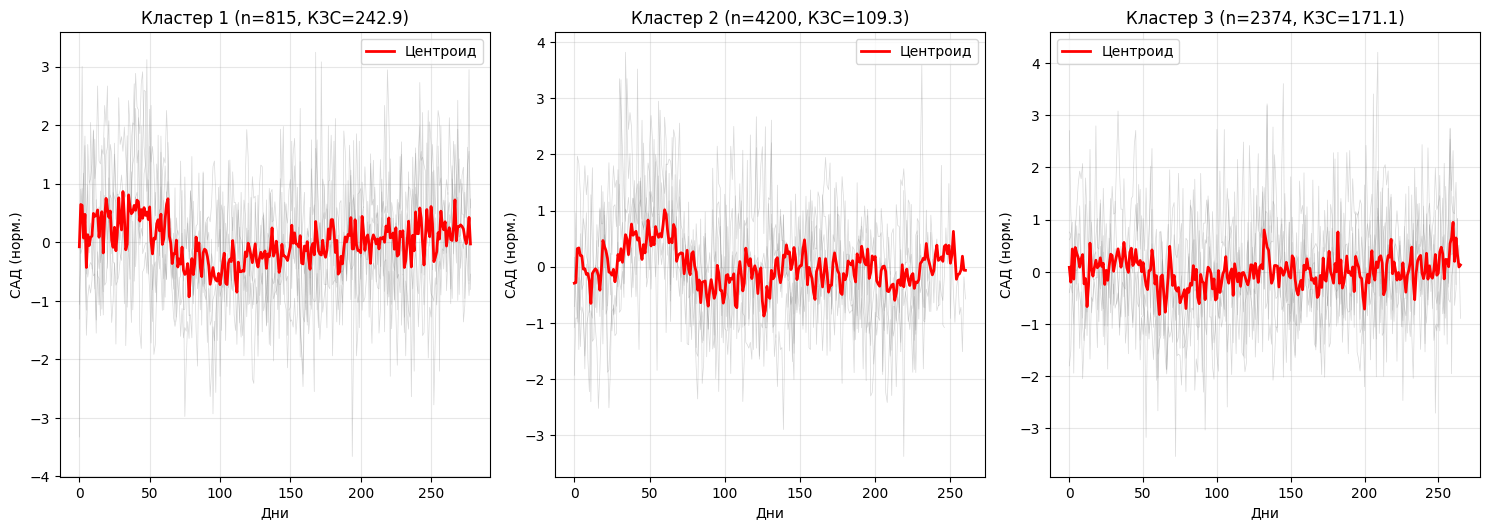

Сохранено: data/photo/cluster_centroids.png


In [16]:
# 2.9 Визуализация кластеров
# Функция для вычисления DTW центроида
def dtw_barycenter_averaging(series_list, max_iter=10):
    """Упрощенная версия DBA"""
    if not series_list:
        return None
    
    # Используем самую длинную серию как начальное приближение
    longest_idx = np.argmax([len(s) for s in series_list])
    centroid = series_list[longest_idx].copy()
    
    # Несколько итераций усреднения
    for _ in range(max_iter):
        aligned_sum = np.zeros_like(centroid, dtype=float)
        aligned_count = np.zeros_like(centroid, dtype=int)
        
        for series in series_list:
            # Простое выравнивание по длине (для демонстрации)
            if len(series) >= len(centroid):
                aligned = series[:len(centroid)]
            else:
                # Интерполяция
                x_old = np.linspace(0, 1, len(series))
                x_new = np.linspace(0, 1, len(centroid))
                aligned = np.interp(x_new, x_old, series)
            
            aligned_sum += aligned
            aligned_count += 1
        
        new_centroid = aligned_sum / aligned_count
        if np.allclose(centroid, new_centroid):
            break
        centroid = new_centroid
    
    return centroid

# Визуализируем центроиды кластеров
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for cluster_id in range(1, optimal_k + 1):
    if cluster_id > len(axes):
        break
        
    ax = axes[cluster_id - 1]
    
    cluster_patients = cluster_df[cluster_df['cluster'] == cluster_id]['patient_id'].tolist()
    
    # Получаем ряды для этих пациентов
    cluster_series = []
    for p in cluster_patients[:10]:  # ограничиваем для скорости
        if p in clustering_series['САД']:
            cluster_series.append(clustering_series['САД'][p])
    
    if cluster_series:
        # Отображаем несколько примеров
        for series in cluster_series[:5]:
            days = np.arange(len(series))
            ax.plot(days, series, alpha=0.3, linewidth=0.5, color='gray')
        
        # Вычисляем и отображаем центроид
        centroid = dtw_barycenter_averaging(cluster_series)
        if centroid is not None:
            days = np.arange(len(centroid))
            ax.plot(days, centroid, linewidth=2, color='red', label='Центроид')
        
        # Статистика
        kzs_mean = cluster_df[cluster_df['cluster'] == cluster_id]['kzs_count'].mean()
        size = len(cluster_patients)
        ax.set_title(f'Кластер {cluster_id} (n={size}, КЗС={kzs_mean:.1f})')
        ax.set_xlabel('Дни')
        ax.set_ylabel('САД (норм.)')
        ax.legend()
        ax.grid(True, alpha=0.3)

# Убираем лишние подграфики
for idx in range(optimal_k, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('data/photo/cluster_centroids.png', dpi=150)
plt.show()
print("Сохранено: data/photo/cluster_centroids.png")

### 2.10 Сохранение всех результатов для следующих этапов

In [17]:
# 2.10 Сохранение всех результатов для следующих этапов
# Сохраняем все результаты
results = {
    'clustering_patients': clustering_patients,
    'cluster_labels': cluster_labels,
    'cluster_df': cluster_df,
    'distance_matrix': distance_matrix,
    'linkage_matrix': linkage_matrix,
    'optimal_k': optimal_k,
    'silhouette_scores': silhouette_scores,
    'k_range': list(k_range),
    'params': {
        'window_days': 7,
        'gamma': 1.0,
        'metric': 'САД'
    }
}

with open('data/clustering_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print(f"Сохранено: data/clustering_results.pkl")
print(f"""
1. Реализован GT-DTW:
   - Функция с временным окном {results['params']['window_days']} дней
   - Параметр gamma = {results['params']['gamma']}
   - Основной показатель: {results['params']['metric']}
2. Вычислена матрица расстояний:
   - Пациентов: {len(clustering_patients)}
   - Размер матрицы: {distance_matrix.shape}
   - Диапазон расстояний: {np.min(distance_matrix[distance_matrix > 0]):.3f} - {np.max(distance_matrix):.3f}
3. Проведена агломеративная кластеризация:
   - Метод linkage: ward
   - Оптимальное число кластеров: {optimal_k}
   - Silhouette score: {np.max(silhouette_scores):.3f}
4. Характеристики кластеров:
""")

for cluster_id in range(1, optimal_k + 1):
    cluster_data = cluster_df[cluster_df['cluster'] == cluster_id]
    print(f"   Кластер {cluster_id}: {len(cluster_data)} пациентов, "
          f"ср. КЗС={cluster_data['kzs_count'].mean():.1f}")

# Очистка памяти
#del distance_matrix, linkage_matrix, clustering_series, clustering_dates
del cluster_df, results
gc.collect()

Сохранено: data/clustering_results.pkl

1. Реализован GT-DTW:
   - Функция с временным окном 7 дней
   - Параметр gamma = 1.0
   - Основной показатель: САД
2. Вычислена матрица расстояний:
   - Пациентов: 7389
   - Размер матрицы: (7389, 7389)
   - Диапазон расстояний: 2.480 - 244.241
3. Проведена агломеративная кластеризация:
   - Метод linkage: ward
   - Оптимальное число кластеров: 3
   - Silhouette score: 0.334
4. Характеристики кластеров:

   Кластер 1: 815 пациентов, ср. КЗС=242.9
   Кластер 2: 4200 пациентов, ср. КЗС=109.3
   Кластер 3: 2374 пациентов, ср. КЗС=171.1


45187